In [5]:
import Hmode_ML_Classifier
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import onnxruntime as ort
import pickle

In [2]:
Model_Choice = 'Ensemble'
ShotRange = [200410, 200939, 201183, 201454, 202029, 202033, 202138, 203011,
             203013, 203036, 203045, 203047, 203092, 203110, 203271, 203297, 
             204049, 204181, 204461, 204463]
Times = np.arange(100,10000,100)
HM = Hmode_ML_Classifier.Hmode_Ml_Predictions(Model_Choice,ShotRange,Times)
Results = HM.Predict()

In [4]:
Results.keys()

dict_keys(['Ensemble', 'ECE', 'PR'])

# ECE Matching

In [24]:
Results['ECE'][0].keys()

dict_keys(['shot', 'errors', 'LH_Label', 'LH_Prob', 'Label_Times', 'Labeling_Errors', 'Feature_Vector'])

In [6]:
with open('./Regression_Test_Data/ECE_Regression_Dict.pkl', 'rb') as file:
    # Load the data from the file
    ECE_Original_Probs = pickle.load(file)

200410
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.19209290e-07
 7.48515129e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.38060951e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
200939
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.54972076e-06 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.000000

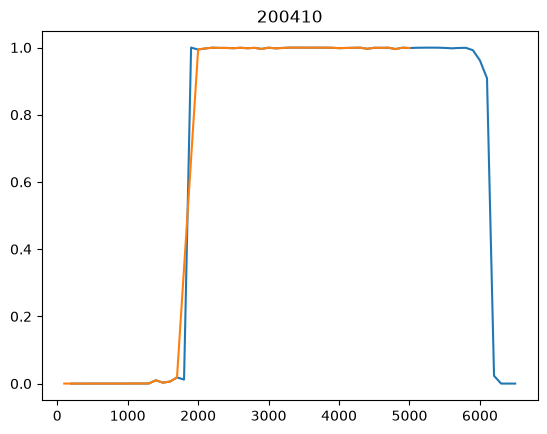

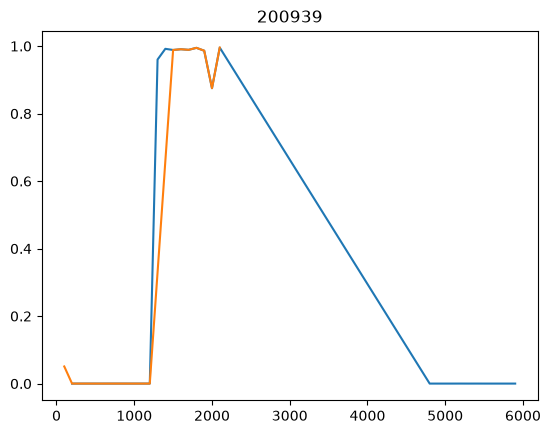

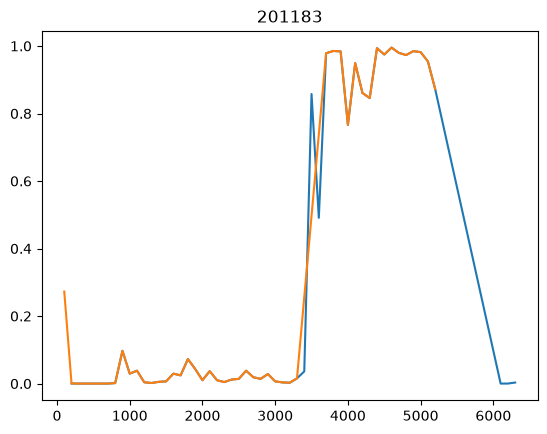

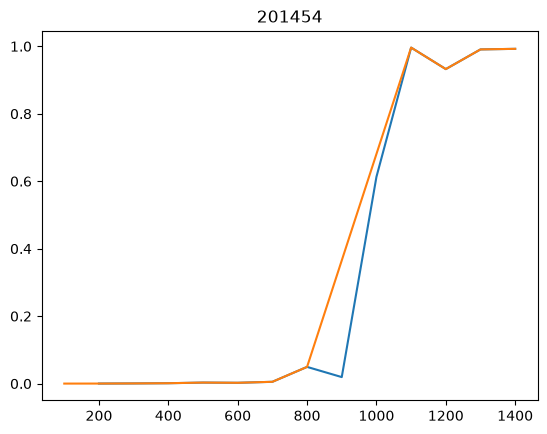

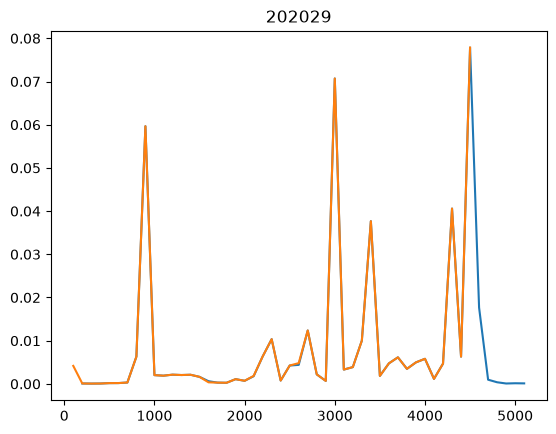

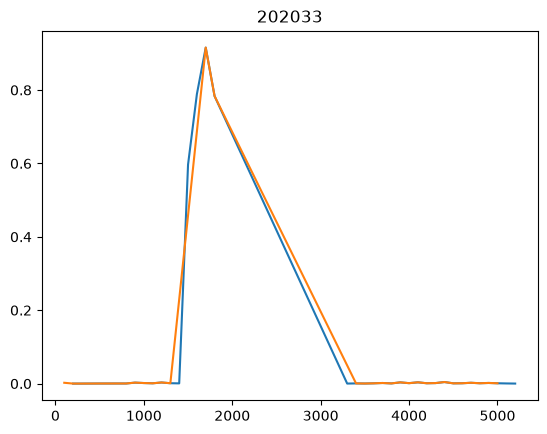

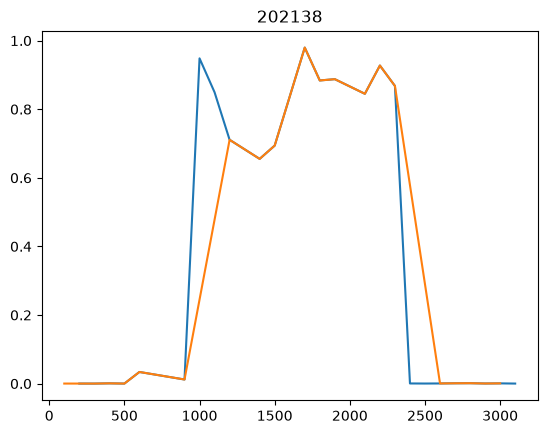

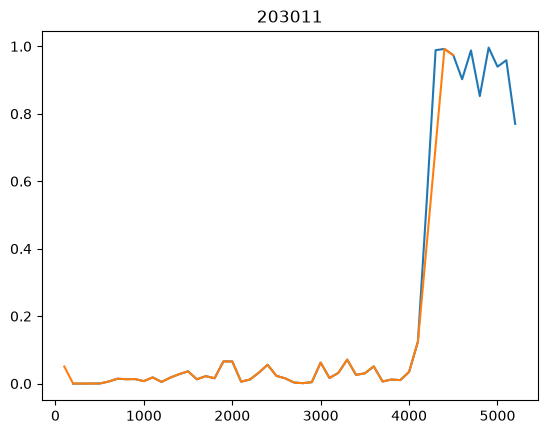

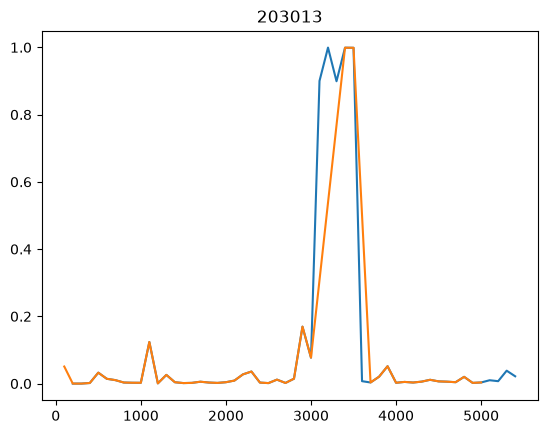

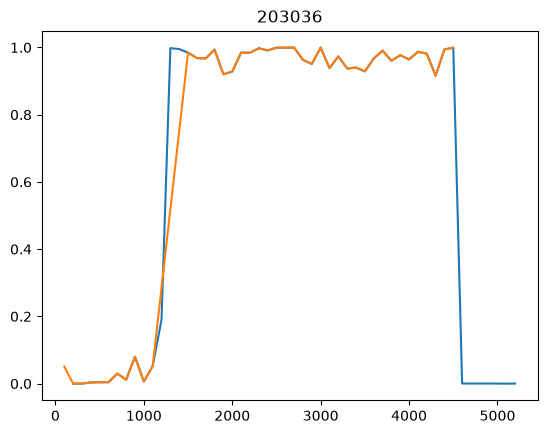

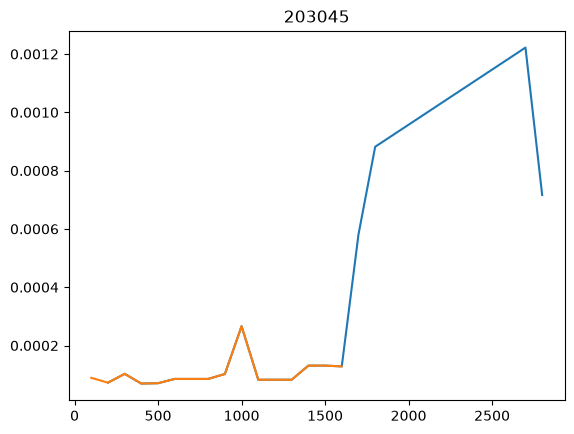

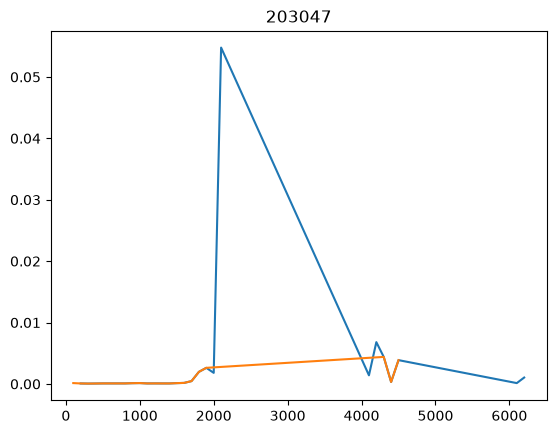

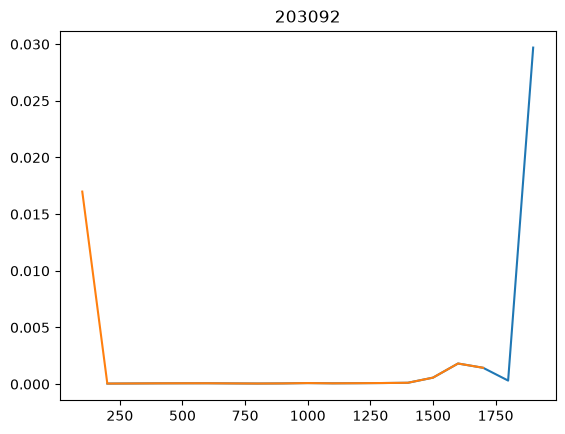

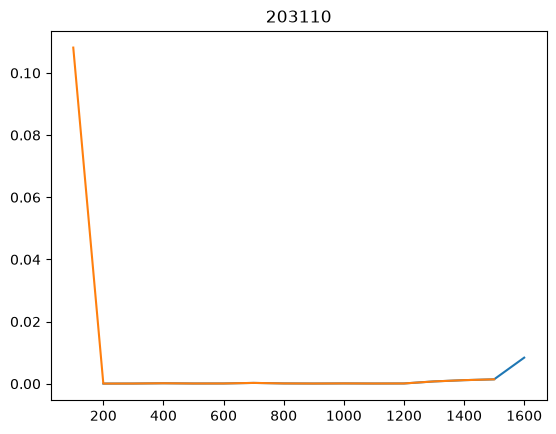

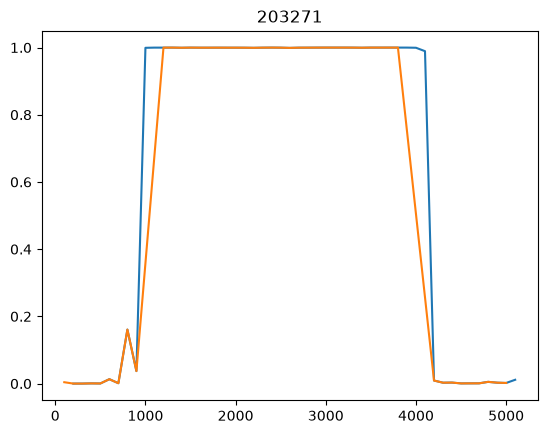

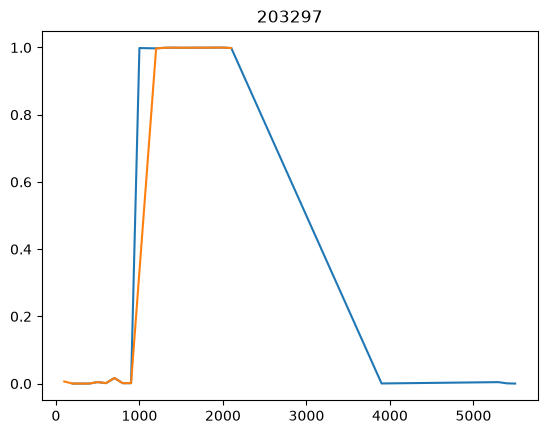

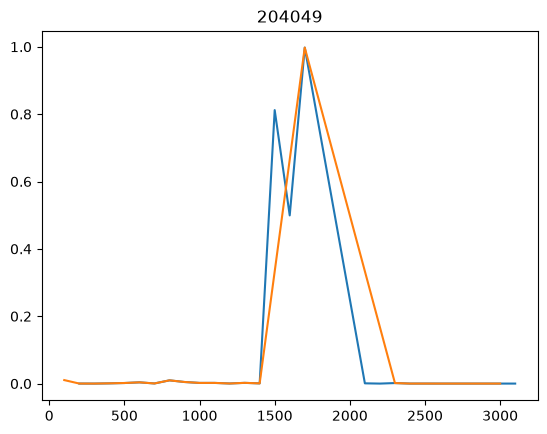

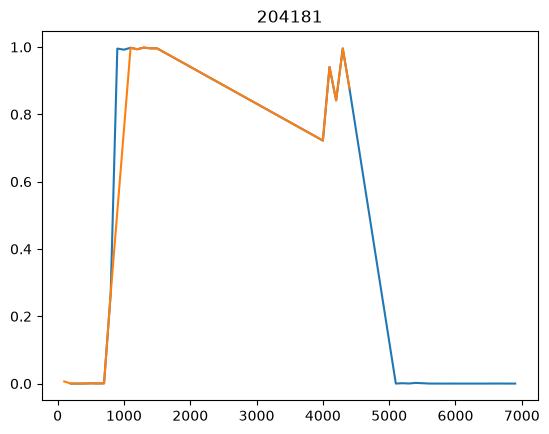

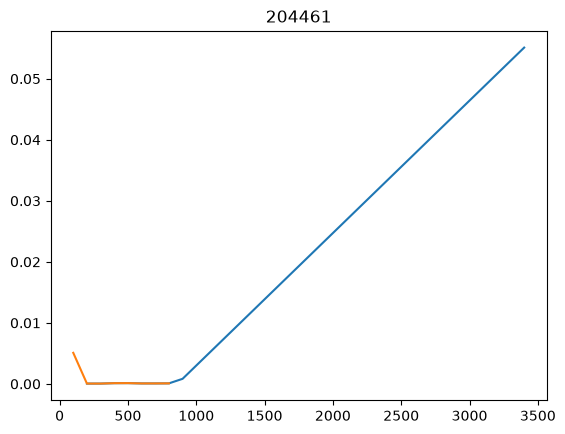

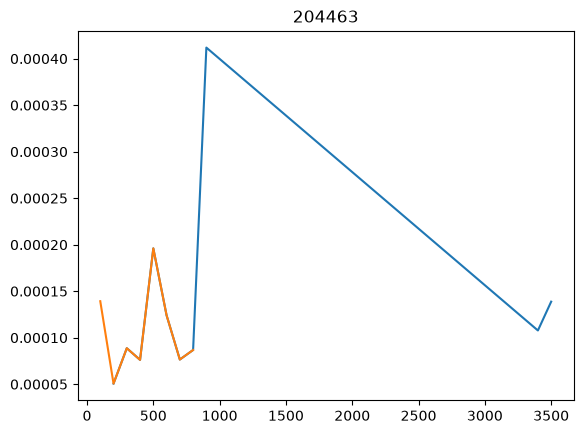

In [29]:
#Let's print their value differences, their average difference, and max difference, then plot their probabilities
for i,shot in enumerate(ShotRange):
    Time = ECE_Original_Probs[shot]['Time']
    H_prob = ECE_Original_Probs[shot]['H_prob']
    
    print(shot)
    fdp_Time = Results['ECE'][i]['Label_Times']
    fdp_H_prob = []
    for j in range(len(Results['ECE'][i]['LH_Prob'])):
        fdp_H_prob.append(Results['ECE'][i]['LH_Prob'][j][1])
    fdp_H_prob = np.asarray(fdp_H_prob)

    Intersection, OG_idx, fdp_idx = np.intersect1d(Time,fdp_Time,return_indices=True)
    
    Error = H_prob[OG_idx] - fdp_H_prob[fdp_idx]
    
    
    plt.figure()
    plt.plot(fdp_Time,fdp_H_prob)
    plt.plot(Time,H_prob)
    plt.title(str(shot))
    print(Error)
    

# PR Test

In [30]:
Results['PR'][0].keys()

dict_keys(['shot', 'errors', 'LH_Label', 'LH_Prob', 'Label_Times', 'Labeling_Errors', 'Feature_Vector'])

In [31]:
with open('./Regression_Test_Data/PR_Regression_Dict.pkl', 'rb') as file:
    # Load the data from the file
    PR_Original_Probs = pickle.load(file)

200410
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
200939
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
201183
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
201454
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
202029
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.00864154  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -0.00065565  0.        ]
202033
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

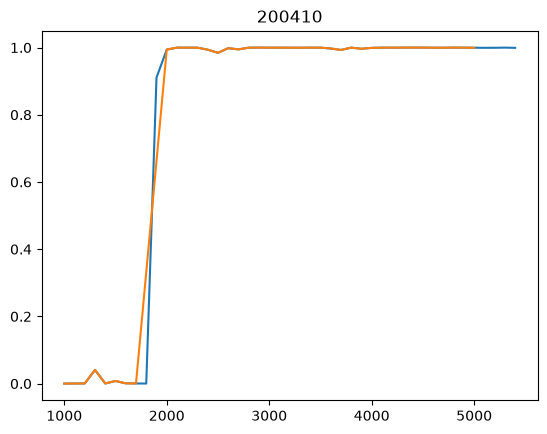

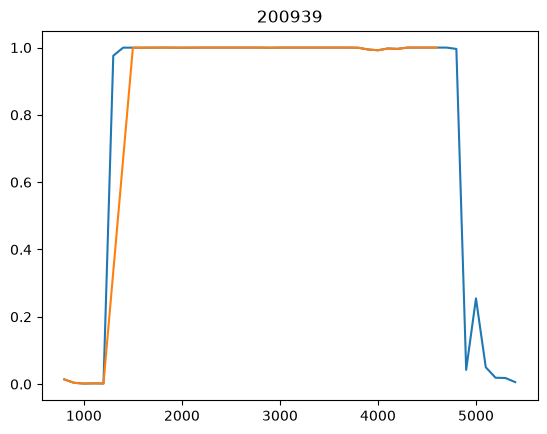

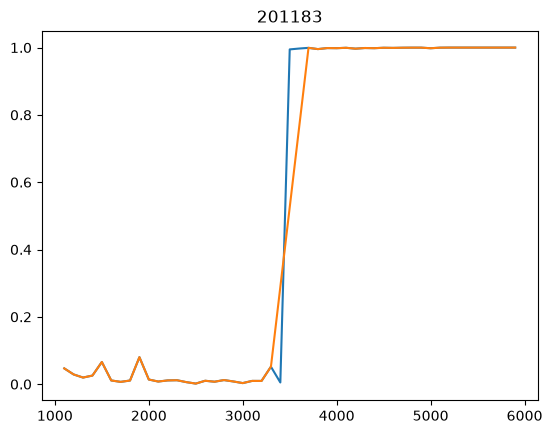

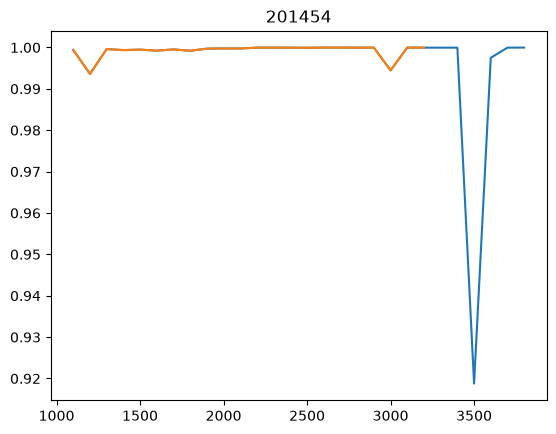

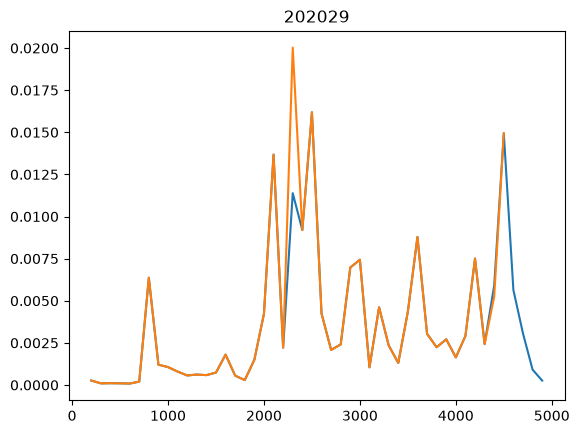

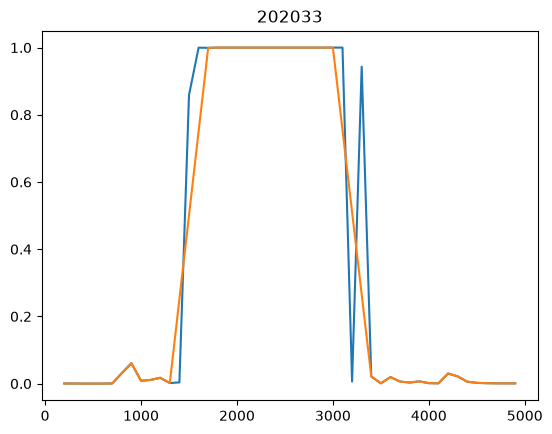

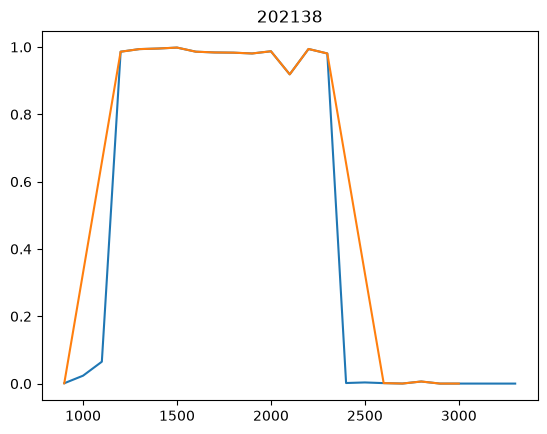

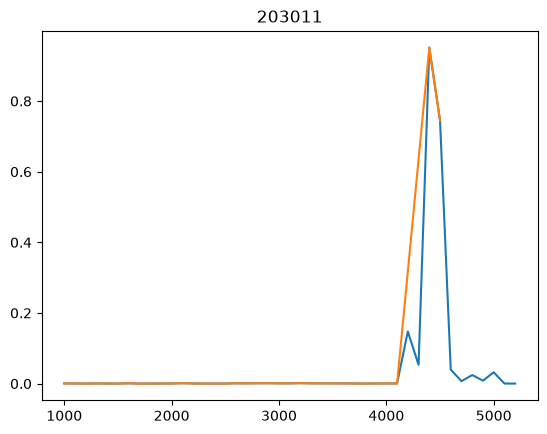

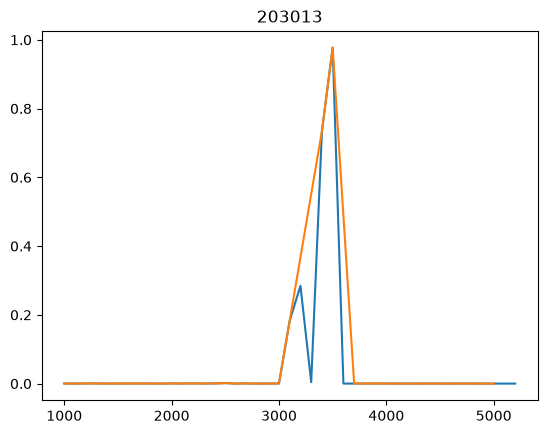

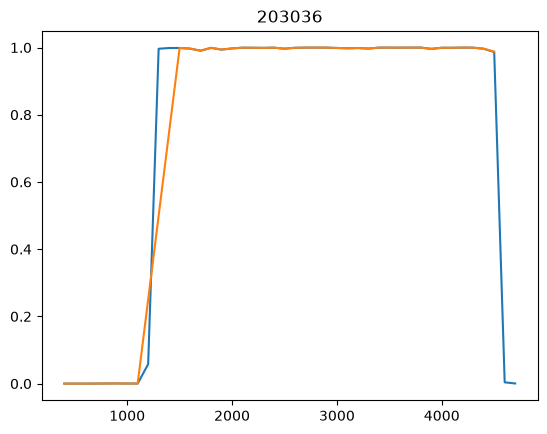

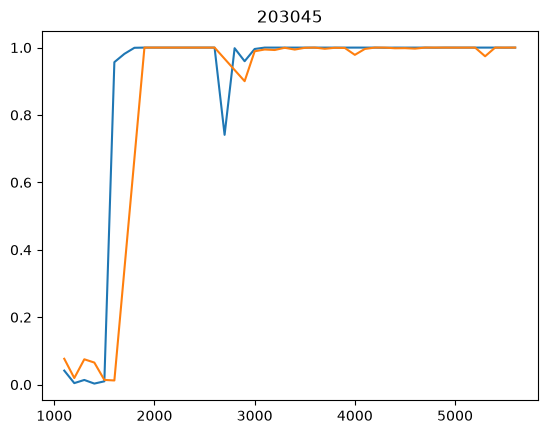

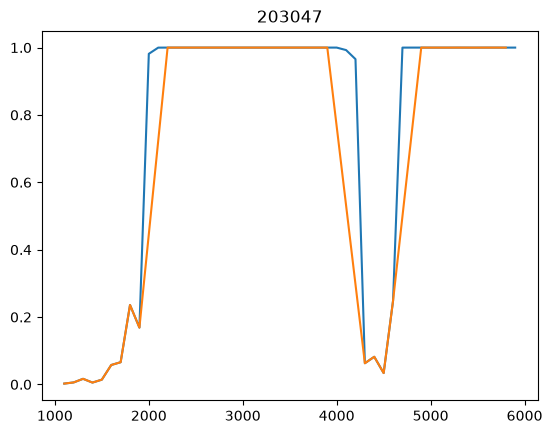

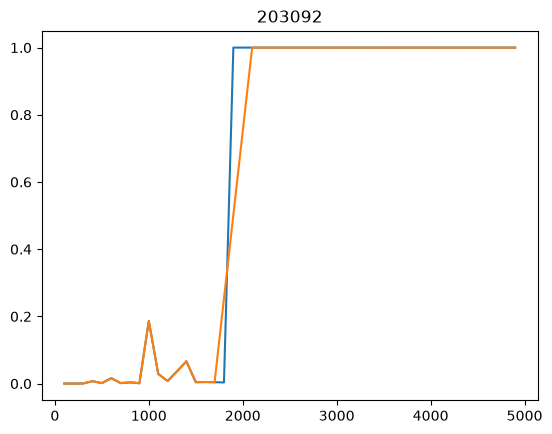

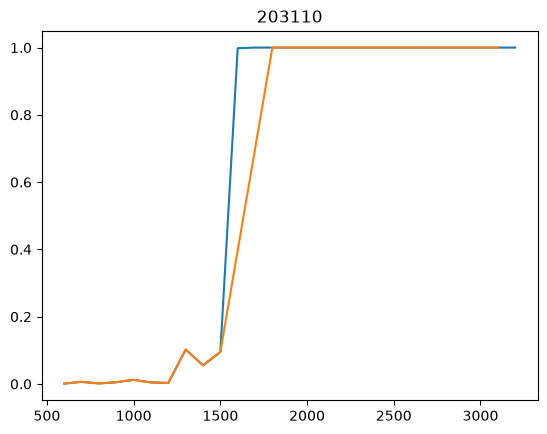

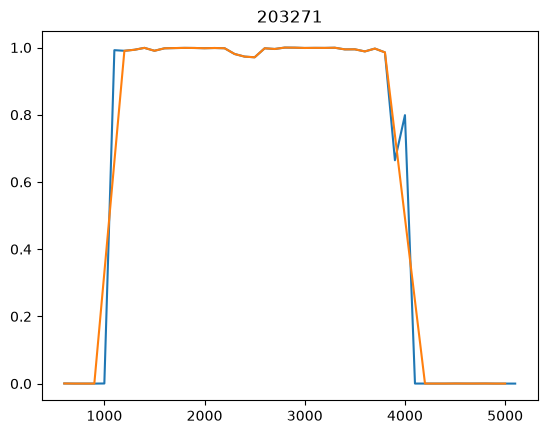

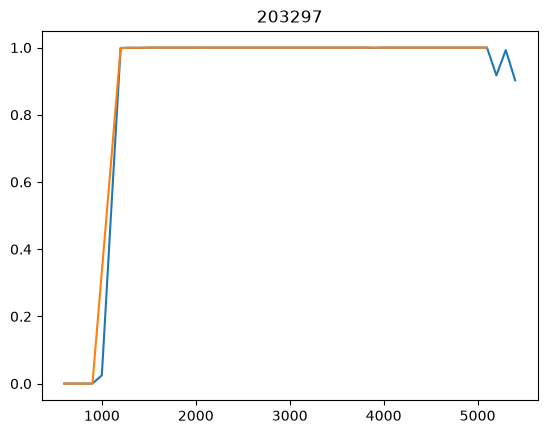

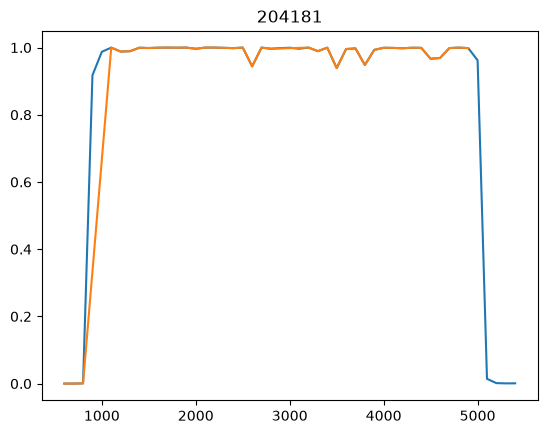

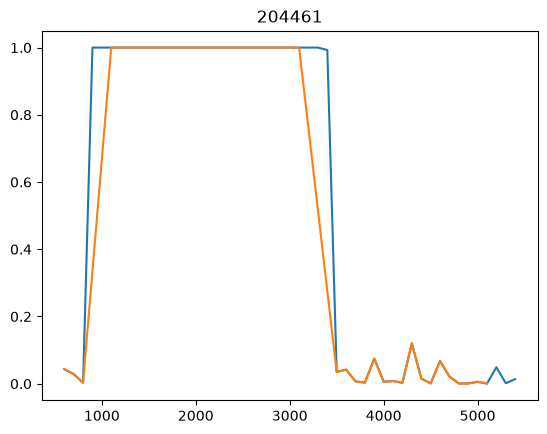

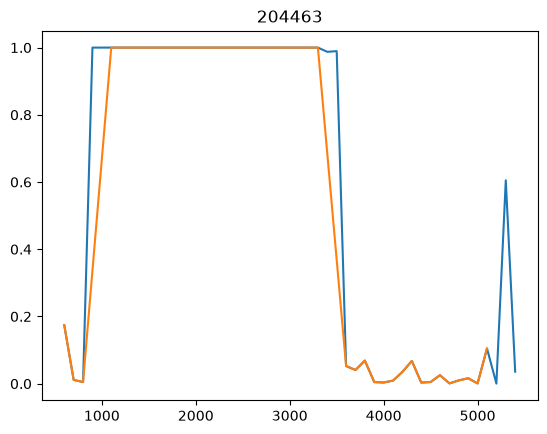

In [33]:
#Let's print their value differences, their average difference, and max difference, then plot their probabilities
for i,shot in enumerate(ShotRange):
    Time = PR_Original_Probs[shot]['Time']
    H_prob = PR_Original_Probs[shot]['H_prob']
    
    print(shot)
    fdp_Time = Results['PR'][i]['Label_Times']
    fdp_H_prob = []
    for j in range(len(Results['PR'][i]['LH_Prob'])):
        fdp_H_prob.append(Results['PR'][i]['LH_Prob'][j][1])
    fdp_H_prob = np.asarray(fdp_H_prob)

    Intersection, OG_idx, fdp_idx = np.intersect1d(Time,fdp_Time,return_indices=True)

    try:
        Error = H_prob[OG_idx] - fdp_H_prob[fdp_idx]
        print(Error)
        
        plt.figure()
        plt.plot(fdp_Time,fdp_H_prob)
        plt.plot(Time,H_prob)
        plt.title(str(shot))
    except:
        print('Error at Shot: '+str(shot))
        print(Intersection)
    

The arrays are almost all 0, the differences, where there are small but non-zero values are likely due to subtle differences in the code where a nighboring data point was picked instead of the original. Shot 203045, must have been recalculated, that is the only explanation for its data returning so different a result.

# Ensemble

In [38]:
Results['Ensemble'][200410].keys()

dict_keys(['shot', 'Time', 'Ensemble_Hmode_Prob', 'Ensemble_Lmode_Prob', 'Ensemble_Label', 'Error'])

In [40]:
with open('./Regression_Test_Data/Ens_Regression_Dict.pkl', 'rb') as file:
    # Load the data from the file
    Ensemble_Original_Probs = pickle.load(file)

200410
[ 1.99269016e-05 -4.03036806e-06 -3.86328636e-05 -7.85176717e-03
  2.31471707e-03 -1.30848204e-03  1.28915407e-03  4.41847811e-03
 -2.54505667e-05  1.35105360e-03  1.18821470e-04  4.09601742e-04
 -2.52344389e-03 -6.74033895e-03 -5.18141556e-04 -1.64800316e-03
  3.62305631e-04  2.04255457e-03  8.28203516e-05  1.09001616e-03
  4.53947382e-04 -3.81766504e-05  5.00975283e-05  8.24329455e-05
 -1.14187204e-03 -3.33960724e-03  9.18802717e-05 -1.39891610e-03
  4.79726352e-04  5.61026872e-04  2.79634207e-04  1.92224250e-04
  1.85721450e-03  3.46868030e-04  2.74865747e-04  6.76808317e-05
  2.21308303e-03  1.43110273e-04  5.03776744e-04]
200939
[-0.00224855 -0.00056587 -0.00024685 -0.00034107 -0.00026558  0.00560481
  0.00453532  0.0054408   0.00256167  0.00673917  0.06219554  0.00210955]
201183
[-9.89880868e-04 -1.48092062e-03 -1.15359210e-03 -1.56041438e-03
 -3.16685525e-03  4.08454697e-04  9.29650393e-04  2.78713792e-03
 -9.09825031e-04 -3.51288938e-04  1.71353226e-03 -7.11667368e-05
 -

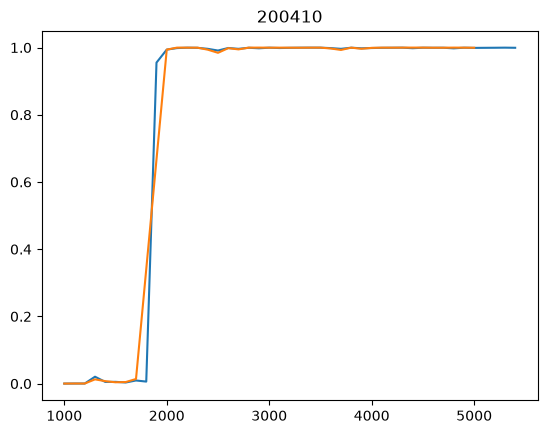

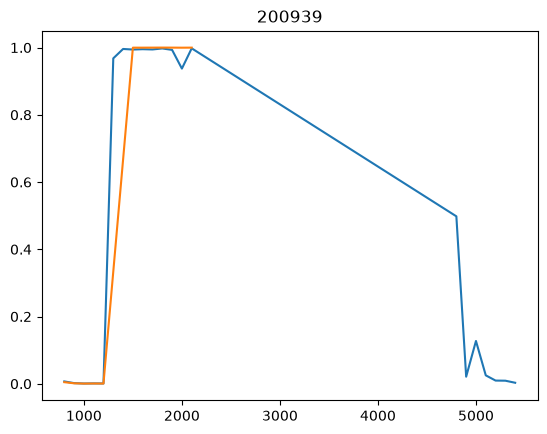

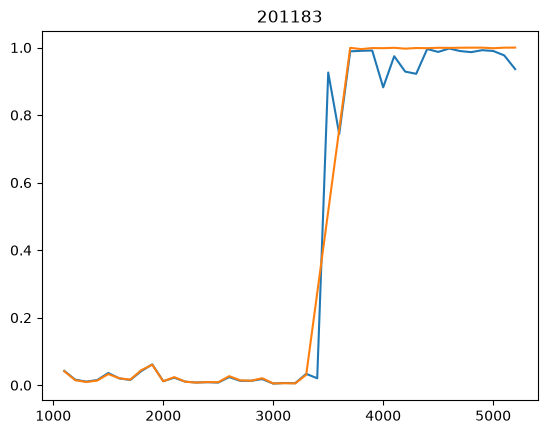

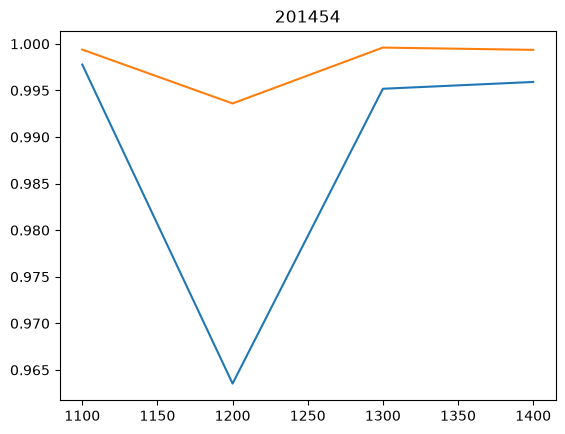

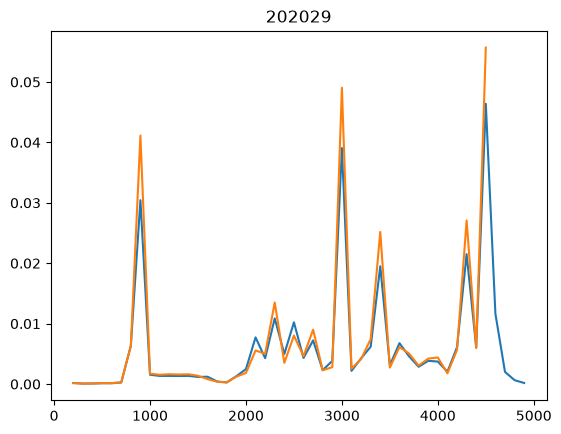

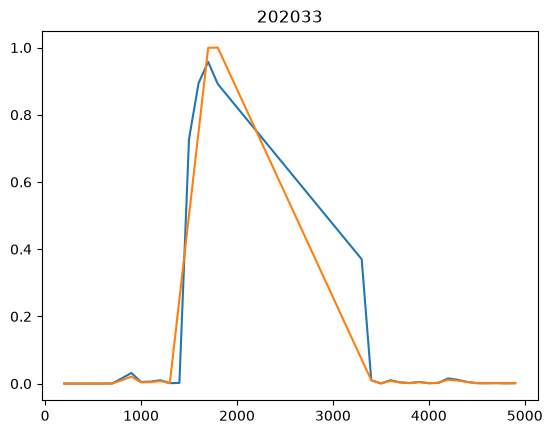

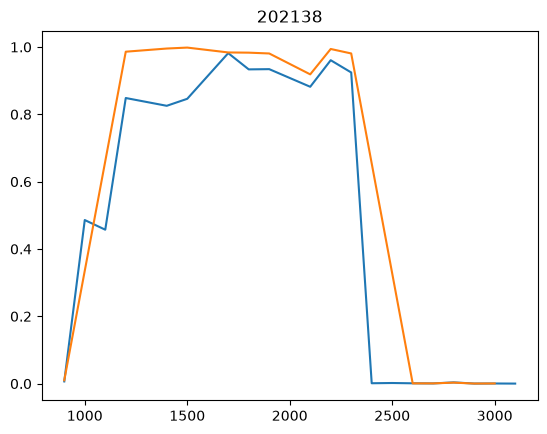

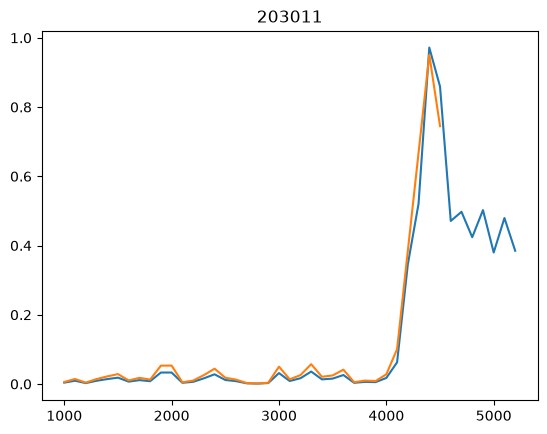

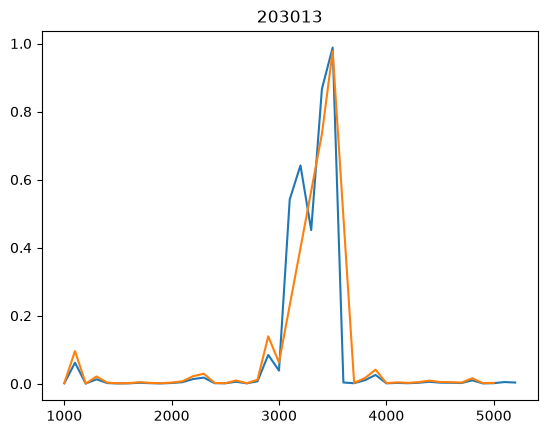

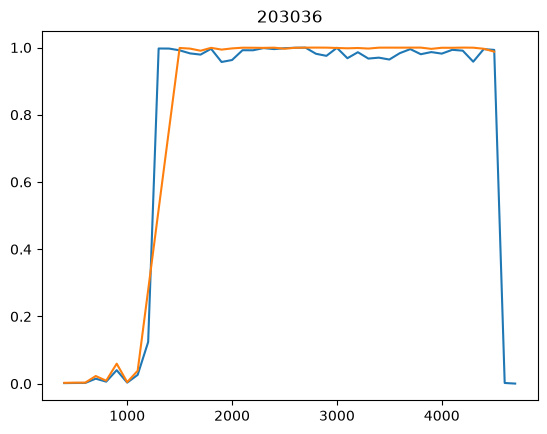

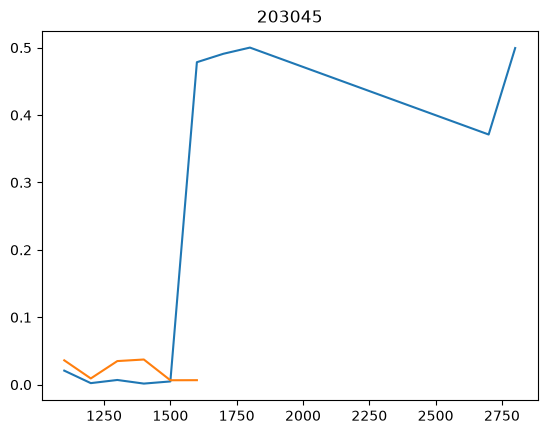

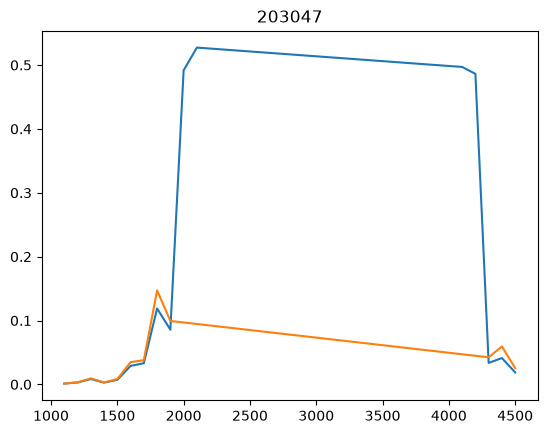

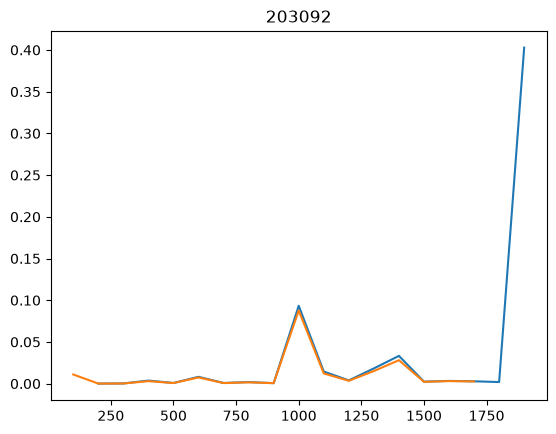

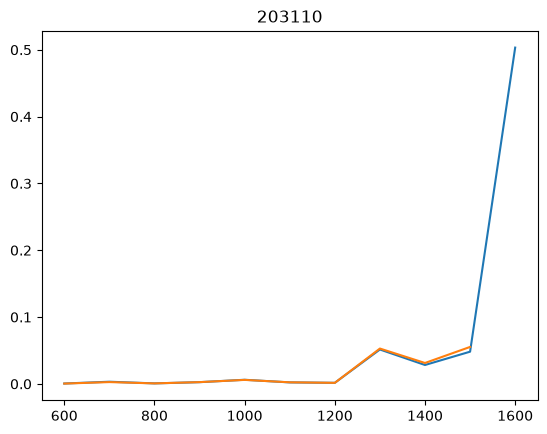

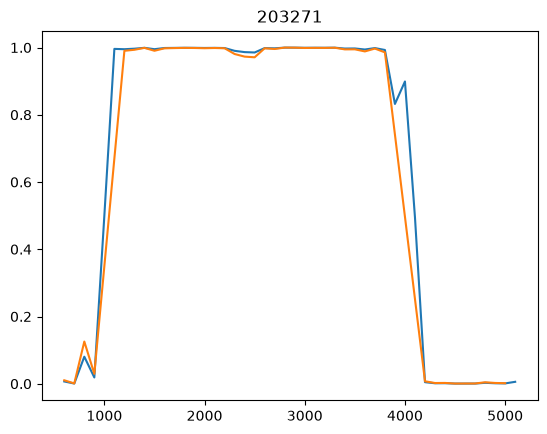

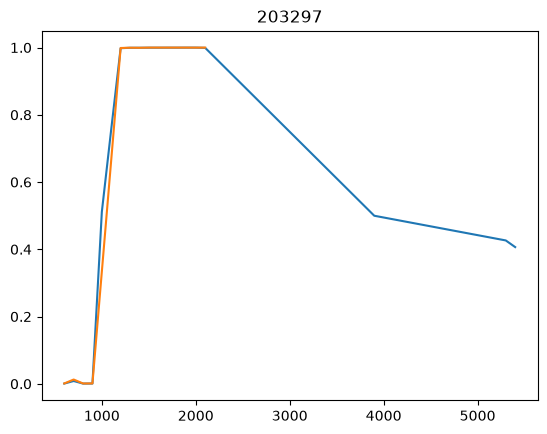

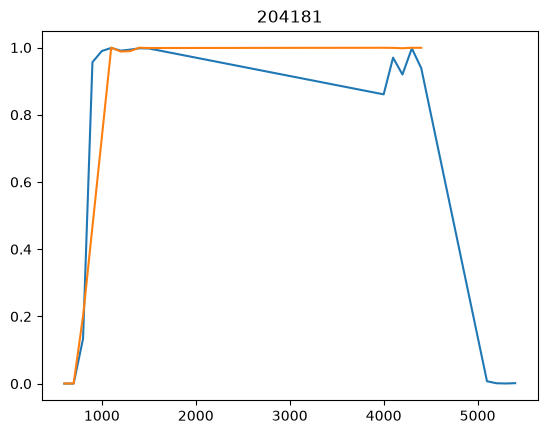

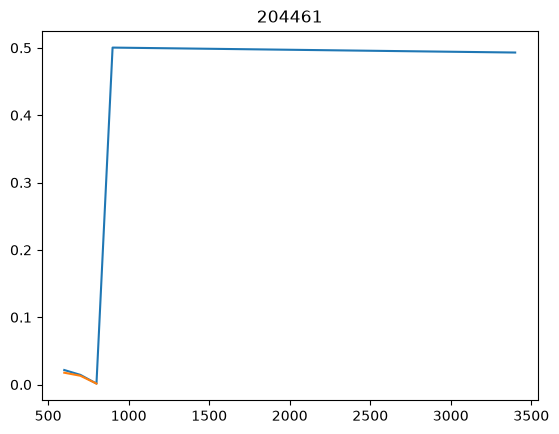

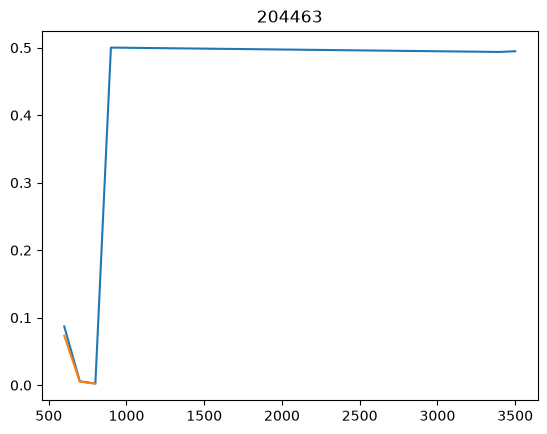

In [43]:
#Let's print their value differences, their average difference, and max difference, then plot their probabilities
for i,shot in enumerate(ShotRange):
    Time = Ensemble_Original_Probs[shot]['Time']
    H_prob = Ensemble_Original_Probs[shot]['H_prob']
    
    print(shot)
    fdp_Time = Results['Ensemble'][shot]['Time']
    fdp_H_prob = Results['Ensemble'][shot]['Ensemble_Hmode_Prob']

    Intersection, OG_idx, fdp_idx = np.intersect1d(Time,fdp_Time,return_indices=True)

    try:
        Error = H_prob[OG_idx] - fdp_H_prob[fdp_idx]
        print(Error)
        
        plt.figure()
        plt.plot(fdp_Time,fdp_H_prob)
        plt.plot(Time,H_prob)
        plt.title(str(shot))
    except:
        print('Error at Shot: '+str(shot))
        print(Intersection)
    

Differences probably arise from numerical error. Strange that there are so many more non-zero terms compared to the previous two models. Especially when considering that the Ensemble model is the simplest, but compounded rounding errors from multiple models is likely the cause of this increased difference. Regardless, the performance is still quite good. The classification accuracy on the training shots will be the final test; if that passes, the package is complete

# Classification Accuracy

In [1]:
import Hmode_ML_Classifier
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import onnxruntime as ort
import pickle

In [2]:
Model_Choice = 'Ensemble'
ShotRange = [202158, 202157, 202156, 202155, 202152, 202141, 202140, 202138, 202112, 202111, 202110, 202109, 202101, 202092, 202041, 202040, 202039, 202037, 202036, 202034, 202033, 202029, 202026, 202020, 202018, 201965, 201964, 201960, 201959, 201955, 201951, 201455, 201454, 201453, 201452, 201451, 201450, 201444, 201439, 201438, 201206, 201205, 201204, 201195, 201190, 201189, 201188, 201186, 201184, 201183, 201172, 201171, 201170, 201169, 201168, 201160, 201150, 201149, 201148, 201134, 201126, 201125, 201124, 200978, 200962, 200961, 200939, 200938, 200929, 200927, 200926, 200925, 200924, 200923, 200876, 200875, 200865, 200864, 200863, 200856, 200855, 200797, 200796, 200784, 200457, 200456, 200455, 200454, 200449, 200448, 200447, 200446, 200440, 200424, 200422, 200420, 200418, 200412, 200410,202981, 202982, 202983, 202984, 202985, 203010, 203011, 203012, 203013, 203033, 203034, 203035, 203036, 203037, 203045, 203047, 203048, 203050, 203091, 203092, 203093, 203094, 203095, 203099, 203100, 203101, 203102, 203104, 203108, 203109, 203110, 203146, 203147, 203148, 203149, 203150, 203190, 203191, 203200, 203201, 203202, 203203, 203204, 203207, 203208, 203209, 203210, 203211, 203212, 203213, 203263, 203264, 203265, 203266, 203267, 203271, 203272, 203273, 203274, 203275, 203286, 203287, 203288, 203289, 203290, 203291, 203292, 203293, 203294, 203297, 203300, 203301, 203305, 203306, 203307, 203311, 203312, 203313, 203314, 203315, 203316, 203317, 203318, 203319, 203320, 203321, 203322, 203323, 203409, 203410, 203411, 203412, 203413, 203414, 203415, 203416, 203417, 203418, 203419, 203420, 203449, 203528, 203529, 203530, 203549, 203551, 203552, 203554, 203595, 203596, 203597, 203598, 203599, 203602, 203603, 203604, 203605, 203606, 203608, 203609, 203610, 203611, 203612, 203676, 203678, 203679, 203680, 203681, 203682, 203683, 203684, 203685, 203686, 203690, 203691, 203827, 203838, 203839, 203873, 203874, 203875, 203876, 203877, 203938, 203939, 203940, 203941, 203942, 203984, 203985, 203986, 203987, 203988, 203989, 203990, 204014, 204047, 204049, 204050, 204052, 204104, 204113, 204173, 204174, 204175, 204176, 204177, 204178, 204180, 204181, 204184, 204191, 204202, 204206, 204275, 204276, 204277, 204278, 204279, 204280, 204281, 204282, 204284, 204396, 204397, 204398, 204399, 204400, 204437, 204439, 204440, 204453, 204454, 204455, 204456, 204457, 204461, 204462, 204463, 204464, 204465] 

Times = np.arange(100,10000,100)
HM = Hmode_ML_Classifier.Hmode_Ml_Predictions(Model_Choice,ShotRange,Times)

In [3]:
%%time
Results = HM.Predict()

/fusion/projects/codes/conda/omega/dev_envs/clarkr/fdp/lib/python3.11/site-packages/sklearn/linear_model/_bayes.py:402: RuntimeWarning: invalid value encountered in sqrt
  y_std = np.sqrt(sigmas_squared_data + (1.0 / self.alpha_))


CPU times: user 8.35 s, sys: 1.35 s, total: 9.7 s
Wall time: 1h 11min 57s


In [20]:
import pandas as pd


def get_modes(shot, times, labels_df):
    """Return the mode for each requested time. Times outside all intervals return -1."""

    shot_df = labels_df[labels_df["Shot"] == shot].sort_values("Begin_Time")

    times = np.asarray(times)
    modes = np.full(len(times), -1, dtype=int)

    for _, row in shot_df.iterrows():

        begin = row["Begin_Time"]
        end = row["End_Time"]
        mode = row["Mode_L0_D1_H2"]

        # Normal interval
        mask = (times >= begin) & (times < end)
        modes[mask] = mode

        # Special boundary handling
        if mode == 0:
            modes[times == end] = 0      # 0/1 boundary -> 0
        elif mode == 2:
            modes[times == begin] = 2    # 1/2 boundary -> 2

    return modes

In [8]:
labels = pd.read_excel("./Regression_Test_Data/Labels.xlsx")

In [12]:
print(Results['ECE'][0].keys())
print(Results['ECE'][0]['shot'])
print(Results['ECE'][0]['LH_Label'])
print(Results['ECE'][0]['Label_Times'])

dict_keys(['shot', 'errors', 'LH_Label', 'LH_Prob', 'Label_Times', 'Labeling_Errors', 'Feature_Vector'])
202158
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[ 200  300  400  500  600  800 1000 1100 1300 1500 1600 1700 1800 1900
 2000 2100 2200 2300 2400 2500 2600 2700 2800 2900 3000]


In [21]:
True_Labels = get_modes(202158,Results['ECE'][0]['Label_Times'],labels)
print(True_Labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


ECE Model Accuracy Test

In [22]:
Correct = 0
Trials = 0
for i,shot in enumerate(ShotRange):
    Model_Labels = Results['ECE'][i]['LH_Label']
    Model_Times = Results['ECE'][i]['Label_Times']
    True_Labels = get_modes(shot,Model_Times,labels)
    for i in range(len(True_Labels)):
        if True_Labels[i] == 0:
            if Model_Labels[i] == 0:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        elif True_Labels[i] == 2:
            if Model_Labels[i] == 1:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        else:
            pass
print('Accuracy of ECE Model is '+str(Correct/Trials*100)+'\%')

Accuracy of ECE Model is 99.68868435300487\%


PR Model Accuracy Test

In [24]:
Correct = 0
Trials = 0
for i,shot in enumerate(ShotRange):
    Model_Labels = Results['PR'][i]['LH_Label']
    Model_Times = Results['PR'][i]['Label_Times']
    True_Labels = get_modes(shot,Model_Times,labels)
    for i in range(len(True_Labels)):
        if True_Labels[i] == 0:
            if Model_Labels[i] == 0:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        elif True_Labels[i] == 2:
            if Model_Labels[i] == 1:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        else:
            pass
print('Accuracy of PR Model is '+str(Correct/Trials*100)+'\%')

Accuracy of PR Model is 99.84397347549083\%


Ensemble Accuracy Test

In [25]:
Results['Ensemble'][200410].keys()

dict_keys(['shot', 'Time', 'Ensemble_Hmode_Prob', 'Ensemble_Lmode_Prob', 'Ensemble_Label', 'Error'])

In [26]:
Correct = 0
Trials = 0
for i,shot in enumerate(ShotRange):
    Model_Labels = Results['Ensemble'][shot]['Ensemble_Label']
    Model_Times = Results['Ensemble'][shot]['Time']
    True_Labels = get_modes(shot,Model_Times,labels)
    for i in range(len(True_Labels)):
        if True_Labels[i] == 0:
            if Model_Labels[i] == 0:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        elif True_Labels[i] == 2:
            if Model_Labels[i] == 1:
                Correct += 1
                Trials += 1
            else:
                Trials += 1
        else:
            pass
print('Accuracy of Ensemble Model is '+str(Correct/Trials*100)+'\%')

Accuracy of Ensemble Model is 99.91463935125907\%


I declare the Regression test Successful in matching the ability of the pretrained models and the performance outlined in the published papers.